## Load the dataset


In [7]:
import pandas as pd

df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Task1 : Identify Data Quality Issues & Check Missing Values

In [8]:

df.info()

print("Duplicates:", df.duplicated().sum())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
Duplicates: 1
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


After checking the dataset, no missing values were found. There is one duplicate records. The data types are appropriate for numerical features (age, bmi, children, charges) and categorical features (sex, smoker, region).

In [9]:

print("Rows before removing duplicates:", len(df))

df = df.drop_duplicates()

print("Rows after removing duplicates:", len(df))

Rows before removing duplicates: 1338
Rows after removing duplicates: 1337


After checking for duplicates, one duplicate row was found and removed. The dataset now contains only unique records, ensuring clean and accurate data for preprocessing.



## Task2: Missing Value Strategy (Mean/Median Imputation)

In [ ]:

# Mean Imputation for 'bmi'
df['bmi'] = df['bmi'].fillna(df['bmi'].mean())

# Median Imputation for 'charges'
df['charges'] = df['charges'].fillna(df['charges'].median())

# Check missing values again
print(df.isnull().sum())

Although this dataset contains no missing values, mean and median imputation techniques could be applied if needed:
 • Mean Imputation replaces missing values with the average, suitable for normally distributed features.
 • Median Imputation replaces missing values with the median, suitable for skewed features or those with outliers.
 In this dataset, no imputation was actually necessary.
 
 

## Task 3: Detect & Handle Outliers (IQR Method)

In [11]:
# Function to remove outliers
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

# Apply to 'bmi' and 'charges'
df = remove_outliers(df, 'bmi')
df = remove_outliers(df, 'charges')


Outliers in bmi and charges were removed using the IQR method to improve data quality.

## Task 4: Normalize Numerical Features

In [14]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd

numerical_cols = ['age','bmi','children','charges']

print("Before Normalization:")
print(df[numerical_cols].head())

# --- Min-Max Scaling ---
minmax = MinMaxScaler()
df_minmax = df.copy()  
df_minmax[numerical_cols] = minmax.fit_transform(df_minmax[numerical_cols])

print("\nAfter Min-Max Scaling:")
print(df_minmax[numerical_cols].head())
print("\nDescription after Min-Max Scaling:")
print(df_minmax[numerical_cols].describe())

# --- Z-score Standardization ---
zscore = StandardScaler()
df_zscore = df.copy() 
df_zscore[numerical_cols] = zscore.fit_transform(df_zscore[numerical_cols])

print("\nAfter Z-score Standardization:")
print(df_zscore[numerical_cols].head())
print("\nDescription after Z-score Standardization:")
print(df_zscore[numerical_cols].describe())


Before Normalization:
        age       bmi  children   charges
0 -1.426004 -0.356550 -0.894896  0.971252
1 -1.497206  0.643355 -0.072559 -1.139086
2 -0.785191  0.512192  1.572115 -0.759890
3 -0.429183 -1.241474 -0.894896  1.681161
4 -0.500385 -0.189615 -0.894896 -0.840995

After Min-Max Scaling:
        age       bmi  children   charges
0  0.021739  0.387788       0.0  0.475058
1  0.000000  0.578435       0.2  0.018193
2  0.217391  0.553426       0.6  0.100285
3  0.326087  0.219065       0.0  0.628746
4  0.304348  0.419617       0.0  0.082727

Description after Min-Max Scaling:
               age          bmi     children      charges
count  1190.000000  1190.000000  1190.000000  1190.000000
mean      0.457125     0.455770     0.217647     0.264793
std       0.305447     0.190745     0.243312     0.216580
min       0.000000     0.000000     0.000000     0.000000
25%       0.173913     0.319584     0.000000     0.099355
50%       0.456522     0.446249     0.200000     0.218699
75%     

Numerical features were normalized using both Min-Max scaling and Z-score standardization. This ensures features are on comparable scales and ready for PCA.



## Task 5: PCA (Principal Component Analysis)

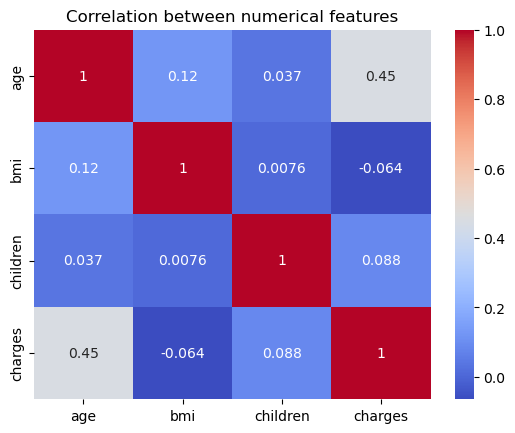


First 5 rows of PCA components:
        PC1       PC2
0 -0.524507 -0.596299
1 -1.778773  0.643790
2 -0.728741  0.203440
3  0.575130 -1.431740
4 -1.110373  0.123053

Explained Variance Ratio:
[0.3672311  0.25874994]


In [15]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- Step 1: Check Correlation ---
sns.heatmap(df_zscore[numerical_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation between numerical features")
plt.show()

# --- Step 2: Apply PCA ---
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_zscore[numerical_cols])

df_pca = pd.DataFrame(df_pca, columns=['PC1','PC2'])
print("\nFirst 5 rows of PCA components:")
print(df_pca.head())

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

Applied PCA on numerical features to reduce dimensionality. PC1 and PC2 capture most of the variance, making the data ready for analysis.
